# VERİ GÖRSELLEŞTİRME

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = 'elektrik_veri_hashed.xlsx'
xls = pd.ExcelFile(file_path)

In [4]:
df_tahsilat = pd.read_excel(xls, sheet_name='Tahsilat')
df_tahsilat_1 = pd.read_excel(xls, sheet_name='Tahsilat 1')
df_tahakkuk = pd.read_excel(xls, sheet_name='Tahakkuk')      # Hamamözü
df_tahakkuk_1 = pd.read_excel(xls, sheet_name='Tahakkuk 1')  # Gümüşhacıköy
df_tahakkuk_2 = pd.read_excel(xls, sheet_name='Tahakkuk 2')  # Göynücek

In [6]:
# Üç ilçenin tahakkuk verilerini alt alta birleştir
df_tum_tahakkuk = pd.concat(
    [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], 
    axis=0, # Satır bazlı (alt alta) birleştirme
    ignore_index=True )# İndeksleri 0'dan başlayarak yeniden düzenle

In [7]:
df_tum_tahakkuk.head()

,il,ilce,sozlesme_hesap_no,mali_yil_donem,fatura_tarihi,kayit_tarihi,vade_tarihi,hesap_sinifi,Hesap Sınıfı,kwh
0,AMASYA,HAMAMÖZÜ,917576806,2023-01-01,2023-01-12,2023-03-06,2023-01-23,M001,Mesken,1.79
1,AMASYA,HAMAMÖZÜ,917576806,2023-01-01,2023-02-09,2023-05-11,2023-02-20,M001,Mesken,2.60
2,AMASYA,HAMAMÖZÜ,917576806,2023-02-01,2023-02-09,2023-05-11,2023-02-20,M001,Mesken,1.23
3,AMASYA,HAMAMÖZÜ,917576806,2023-02-01,2023-03-10,2023-05-11,2023-03-20,M001,Mesken,2.56
4,AMASYA,HAMAMÖZÜ,917576806,2023-03-01,2023-03-10,2023-05-11,2023-03-20,M001,Mesken,1.35


In [18]:
df_tahakkuk["Hesap Sınıfı"].unique()

array(['Mesken', 'Ticari Faaliyet - Yazıhane',
       'Tarımsal Faaliyetler (Şahıs)', 'Şantiye ve Geçici Aboneler',
       'Balıkçılık ve Su Ürünleri Yetiştiriciliğ',
       'Kar Amacı Güden Dernek,Vakıf,Müze', 'Şehit Aileleri ve Gaziler',
       'Resmi Üniversite,Yük.Okul,Kurs,Yurt,Okul', 'Belediye',
       '1 SAYILI CETVELDE YER ALAN KAMU İDARESİ',
       'Resmi Hayır Kurumları,Dernek,Vakıf,Müze', 'Resmi Daire',
       'İbadethane Isıtma/Soğutma/Lojman',
       'Ölçümsüz Aboneler (Resmi Daire)', 'İçme-Kullanma Suyu (Belediye)',
       'Süt Toplama Merkezi', 'Büyükbaş-Küçükbaş Hayvancılık',
       'Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)', 'Sanayi',
       'Resmi Daire Lojman', 'İktisadi İşletmeleri Hariç Dernek ve Vkf',
       'Cemevleri', 'Tarımsal Faaliyetler (Kooperatif)',
       'Köy İçme Suyu Temini ve Dağıtımı Tesisi', 'İbadethane Aydınlatma',
       'Resmi SAĞLIK KURULUŞLARI,RESMİ SPOR TES.',
       'Muhtarlık Hizmet Binaları', 'Lisansız Üreticiler'], dtype=object)

In [19]:
df_tahakkuk_1["Hesap Sınıfı"].unique()

array(['Mesken', 'Ticari Faaliyet - Yazıhane', 'Cemevleri',
       'Tarımsal Faaliyetler (Şahıs)', 'Şehit Aileleri ve Gaziler',
       'Resmi Üniversite,Yük.Okul,Kurs,Yurt,Okul',
       'Şantiye ve Geçici Aboneler',
       'Balıkçılık ve Su Ürünleri Yetiştiriciliğ',
       'Kar Amacı Güden Dernek,Vakıf,Müze', 'Sanayi',
       '1 SAYILI CETVELDE YER ALAN KAMU İDARESİ', 'İbadethane Aydınlatma',
       'Resmi Daire', 'Resmi Daire Lojman',
       'İbadethane Isıtma/Soğutma/Lojman', 'Belediye',
       'İçme-Kullanma Suyu (Belediye)',
       'Resmi Hayır Kurumları,Dernek,Vakıf,Müze',
       'Tarımsal Faaliyetler (Kooperatif)',
       'Belediye Park Bahçe Aydınlatma',
       'İktisadi İşletmeleri Hariç Dernek ve Vkf',
       'Ölçümsüz Aboneler (Resmi Daire)',
       'Resmi SAĞLIK KURULUŞLARI,RESMİ SPOR TES.',
       'Köy İçme Suyu Temini ve Dağıtımı Tesisi', 'Süt Toplama Merkezi',
       'Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)', 'İç Tüketim',
       'Karayolları Genel Müdürlüğü Aydınlatma', '

In [20]:
df_tahakkuk_2["Hesap Sınıfı"].unique()

array(['Mesken', 'Ticari Faaliyet - Yazıhane',
       'Tarımsal Faaliyetler (Şahıs)', 'Resmi Daire',
       'Şehit Aileleri ve Gaziler', 'Şantiye ve Geçici Aboneler',
       'Resmi Üniversite,Yük.Okul,Kurs,Yurt,Okul', 'Belediye',
       'İbadethane Isıtma/Soğutma/Lojman',
       'Resmi Hayır Kurumları,Dernek,Vakıf,Müze',
       '1 SAYILI CETVELDE YER ALAN KAMU İDARESİ',
       'Kar Amacı Güden Dernek,Vakıf,Müze',
       'Köy İçme Suyu Temini ve Dağıtımı Tesisi',
       'İçme-Kullanma Suyu (Belediye)',
       'Tarımsal Faaliyetler (Kooperatif)', 'Sanayi',
       'Ölçümsüz Aboneler (Resmi Daire)', 'Resmi Daire Lojman',
       'Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)', 'İbadethane Aydınlatma',
       'Resmi İbadethane Isıtma/Soğutma/Lojman', 'Süt Toplama Merkezi',
       'Büyükbaş-Küçükbaş Hayvancılık',
       'İktisadi İşletmeleri Hariç Dernek ve Vkf', 'Cemevleri',
       'İç Tüketim', 'Resmi SAĞLIK KURULUŞLARI,RESMİ SPOR TES.',
       'Muhtarlık Hizmet Binaları', 'Lisansız Üreticiler'], 

In [22]:
df_tahakkuk["Hesap Sınıfı"].value_counts()

Hesap Sınıfı
Mesken                                      110682
Ticari Faaliyet - Yazıhane                    7468
1 SAYILI CETVELDE YER ALAN KAMU İDARESİ       1510
İbadethane Isıtma/Soğutma/Lojman              1443
Tarımsal Faaliyetler (Şahıs)                   661
İbadethane Aydınlatma                          528
Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)         495
Şantiye ve Geçici Aboneler                     402
Resmi Daire Lojman                             177
Köy İçme Suyu Temini ve Dağıtımı Tesisi        177
Resmi Daire                                    149
Belediye                                       147
Süt Toplama Merkezi                            127
Resmi Hayır Kurumları,Dernek,Vakıf,Müze        127
Şehit Aileleri ve Gaziler                      120
Resmi SAĞLIK KURULUŞLARI,RESMİ SPOR TES.       113
Büyükbaş-Küçükbaş Hayvancılık                  107
İktisadi İşletmeleri Hariç Dernek ve Vkf        76
Balıkçılık ve Su Ürünleri Yetiştiriciliğ        63
Resmi Üniversite,Y

In [23]:
df_tahakkuk_1["Hesap Sınıfı"].value_counts()

Hesap Sınıfı
Mesken                                      658189
Ticari Faaliyet - Yazıhane                   63600
Tarımsal Faaliyetler (Şahıs)                 13987
İbadethane Isıtma/Soğutma/Lojman              5740
Şantiye ve Geçici Aboneler                    5053
1 SAYILI CETVELDE YER ALAN KAMU İDARESİ       4844
Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)        2356
İbadethane Aydınlatma                         1845
Şehit Aileleri ve Gaziler                     1756
Belediye                                      1121
Köy İçme Suyu Temini ve Dağıtımı Tesisi        978
Tarımsal Faaliyetler (Kooperatif)              803
Süt Toplama Merkezi                            720
Büyükbaş-Küçükbaş Hayvancılık                  711
Resmi Daire                                    669
Cemevleri                                      611
Belediye Park Bahçe Aydınlatma                 349
Resmi Daire Lojman                             346
İçme-Kullanma Suyu (Belediye)                  340
Resmi Üniversite,Y

In [24]:
df_tahakkuk_2["Hesap Sınıfı"].value_counts()

Hesap Sınıfı
Mesken                                      257738
Ticari Faaliyet - Yazıhane                   20230
İbadethane Isıtma/Soğutma/Lojman              2990
Tarımsal Faaliyetler (Şahıs)                  2618
1 SAYILI CETVELDE YER ALAN KAMU İDARESİ       2146
Köy İçme Suyu Temini ve Dağıtımı Tesisi       1305
Şantiye ve Geçici Aboneler                    1251
Büyükbaş-Küçükbaş Hayvancılık                 1031
Belediye                                       829
İbadethane Aydınlatma                          816
Tarımsal Faaliyetler (Kooperatif)              815
Şehit Aileleri ve Gaziler                      795
Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)         654
Resmi Daire                                    555
Süt Toplama Merkezi                            281
Cemevleri                                      272
Muhtarlık Hizmet Binaları                      195
Resmi Üniversite,Yük.Okul,Kurs,Yurt,Okul       136
Resmi SAĞLIK KURULUŞLARI,RESMİ SPOR TES.       110
İktisadi İşletmele

/var/folders/vz/31v7p06j097_ztrpd85j8t_m0000gn/T/ipykernel_4145/3255601992.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_6.values, y=top_6.index, ax=axes[i], palette=palet)
/var/folders/vz/31v7p06j097_ztrpd85j8t_m0000gn/T/ipykernel_4145/3255601992.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_6.values, y=top_6.index, ax=axes[i], palette=palet)
/var/folders/vz/31v7p06j097_ztrpd85j8t_m0000gn/T/ipykernel_4145/3255601992.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_6.values, y=top_6.index, ax=axes[i], pale

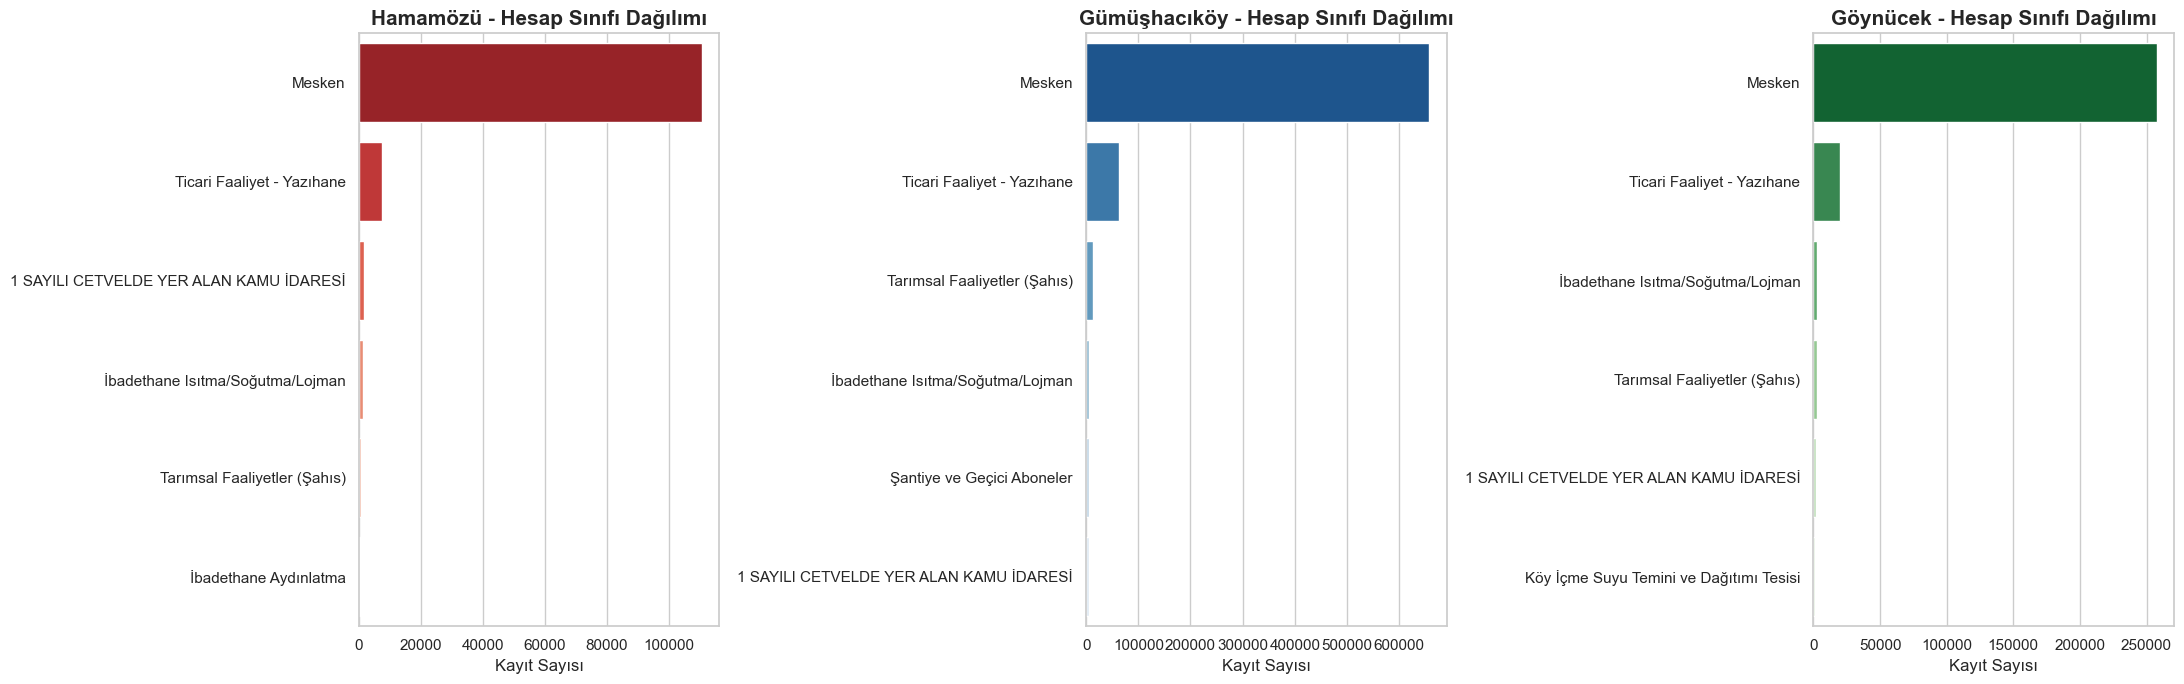

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# 2. İlçe veri setlerini ve isimlerini eşleştir
ilceler = [
    (df_tahakkuk, 'Hamamözü', 'Reds_r'),
    (df_tahakkuk_1, 'Gümüşhacıköy', 'Blues_r'),
    (df_tahakkuk_2, 'Göynücek', 'Greens_r')
]

# 3. Döngü ile her ilçe için grafik oluştur
for i, (df, ad, palet) in enumerate(ilceler):
    # En yaygın 6 hesap sınıfını al (Görsel netliği için)
    top_6 = df['Hesap Sınıfı'].value_counts().head(6)
    
    # İlgili subplot kutusuna (axes[i]) çizdir
    sns.barplot(x=top_6.values, y=top_6.index, ax=axes[i], palette=palet)
    
    # Başlık ve eksen ayarları
    axes[i].set_title(f'{ad} - Hesap Sınıfı Dağılımı', fontsize=15, fontweight='bold')
    axes[i].set_xlabel('Kayıt Sayısı', fontsize=12)
    axes[i].set_ylabel('') # Y ekseni ismini temizle

# 4. Yerleşimi optimize et ve göster
plt.tight_layout()
plt.show()

In [32]:
# Her DataFrame için tarih dönüşümü
for df in [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2]:
    # String formatındaki tarihi datetime objesine çevir
    df['mali_yil_donem'] = pd.to_datetime(df['mali_yil_donem'])
    # Tarihten ay bilgisini çek
    df['ay'] = df['mali_yil_donem'].dt.month

In [33]:
# Her ilçe için aylık ortalama tüketimi hesapla
hamamozu_trend = df_tahakkuk.groupby('ay')['kwh'].mean()
gumushacikoy_trend = df_tahakkuk_1.groupby('ay')['kwh'].mean()
goynucek_trend = df_tahakkuk_2.groupby('ay')['kwh'].mean()

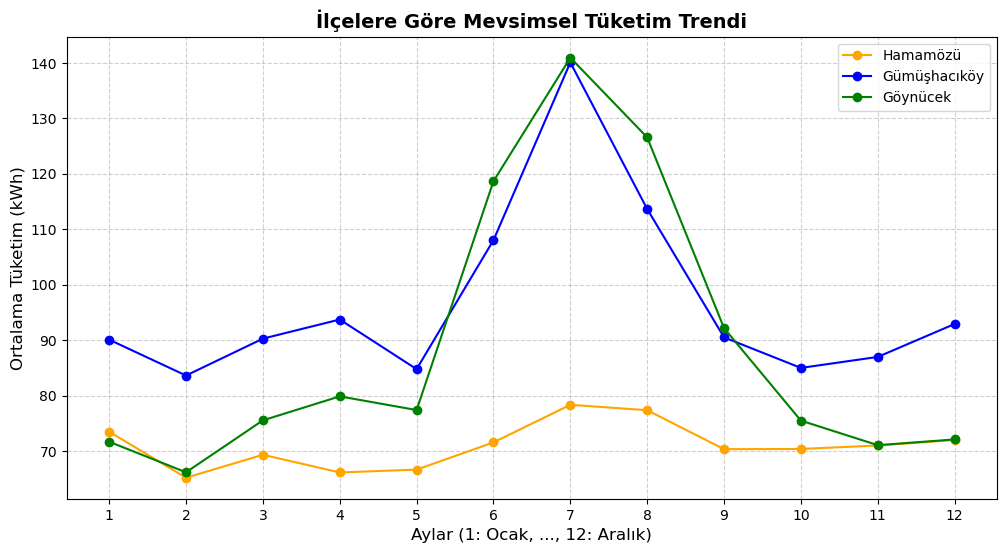

In [34]:

plt.figure(figsize=(12, 6))

# Çizgi grafiklerini ekle
plt.plot(hamamozu_trend.index, hamamozu_trend.values, marker='o', label='Hamamözü', color='orange')
plt.plot(gumushacikoy_trend.index, gumushacikoy_trend.values, marker='o', label='Gümüşhacıköy', color='blue')
plt.plot(goynucek_trend.index, goynucek_trend.values, marker='o', label='Göynücek', color='green')

# Grafik süslemeleri
plt.title('İlçelere Göre Mevsimsel Tüketim Trendi', fontsize=14, fontweight='bold')
plt.xlabel('Aylar (1: Ocak, ..., 12: Aralık)', fontsize=12)
plt.ylabel('Ortalama Tüketim (kWh)', fontsize=12)
plt.xticks(range(1, 13)) # X ekseninde tüm ayları göster
plt.legend() # Hangi rengin hangi ilçe olduğunu gösteren kutu
plt.grid(True, linestyle='--', alpha=0.6) # Okunabilirliği artıran kareli arka plan

plt.show()

/var/folders/vz/31v7p06j097_ztrpd85j8t_m0000gn/T/ipykernel_4145/3312067513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ilce_counts.index, y=ilce_counts.values, ax=axes[0], palette='viridis')
/var/folders/vz/31v7p06j097_ztrpd85j8t_m0000gn/T/ipykernel_4145/3312067513.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sube_counts.values, y=sube_counts.index, ax=axes[1], palette='magma')


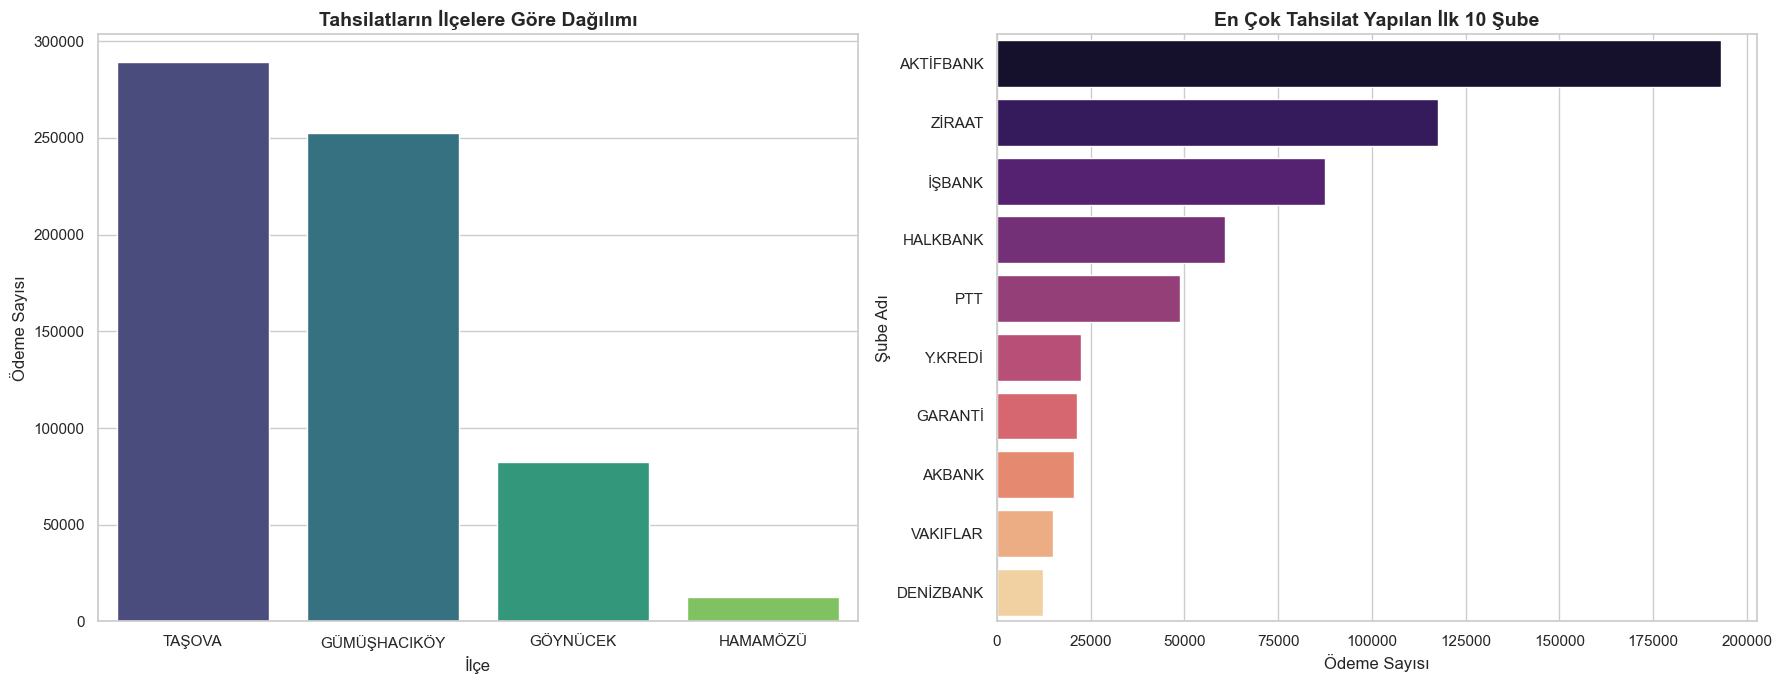

In [35]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#İlçe Dağılımı
# Tahsilat sayfasındaki ilçe dağılımını hesapla
ilce_counts = df_tahsilat['İlçe'].value_counts()
sns.barplot(x=ilce_counts.index, y=ilce_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Tahsilatların İlçelere Göre Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('İlçe')
axes[0].set_ylabel('Ödeme Sayısı')

#Şube Dağılımı (Top 10) ---
# Şube sayısı çok fazla olabileceği için en çok işlem yapılan ilk 10 şubeyi gösterelim
sube_counts = df_tahsilat['Şube'].value_counts().head(10)
sns.barplot(x=sube_counts.values, y=sube_counts.index, ax=axes[1], palette='magma')
axes[1].set_title('En Çok Tahsilat Yapılan İlk 10 Şube', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ödeme Sayısı')
axes[1].set_ylabel('Şube Adı')

plt.tight_layout()
plt.show()

In [44]:
# Veri seti özetindeki referans oranlar
labels = ['Zamanında/Erken Ödeme', 'Geç Ödeme']
sizes = [86.0, 27.2] # Not: Toplam 100'ü geçebilir (kısmi ödemelerden dolayı)

# Eğer sadece bu iki kategorinin kendi içindeki dağılımını %100 üzerinden görmek istersen:
normalized_sizes = [size / sum(sizes) * 100 for size in sizes]

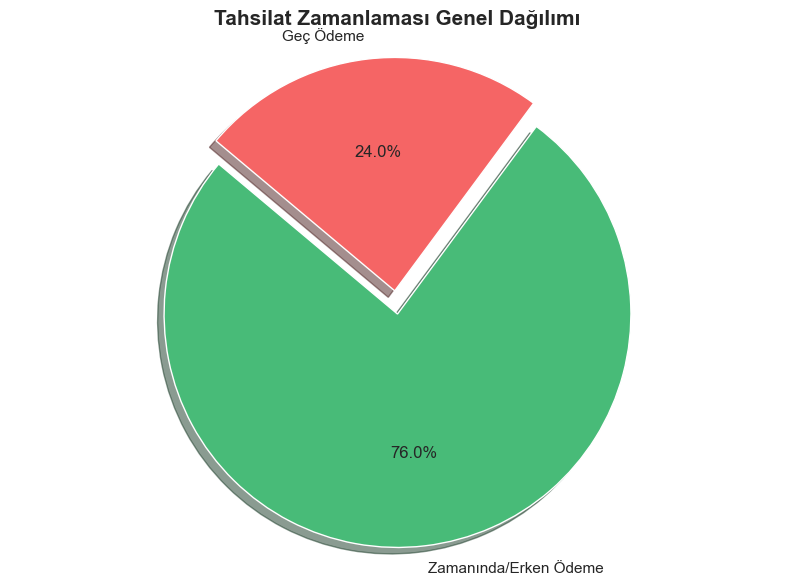

In [45]:
# Renkleri ve patlama efektini (explode) ayarla
colors = ['#48bb78', '#f56565'] # Yeşil (Başarı), Kırmızı (Risk)
explode = (0.1, 0)  # İlk dilimi (Zamanında) biraz dışarı çıkar

plt.figure(figsize=(10, 7))
plt.pie(normalized_sizes, 
        explode=explode, 
        labels=labels, 
        colors=colors,
        autopct='%1.1f%%', # Yüzdelik dilimleri göster
        shadow=True, 
        startangle=140)

plt.title('Tahsilat Zamanlaması Genel Dağılımı', fontsize=15, fontweight='bold')
plt.axis('equal') # Grafiğin tam daire görünmesini sağlar
plt.show()

In [46]:
# IQR 
Q1 = df_tum_tahakkuk['kwh'].quantile(0.25)
Q3 = df_tum_tahakkuk['kwh'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"İstatistiksel Üst Sınır (Outlier Eşiği): {ust_sinir:.2f} kWh")

İstatistiksel Üst Sınır (Outlier Eşiği): 172.98 kWh


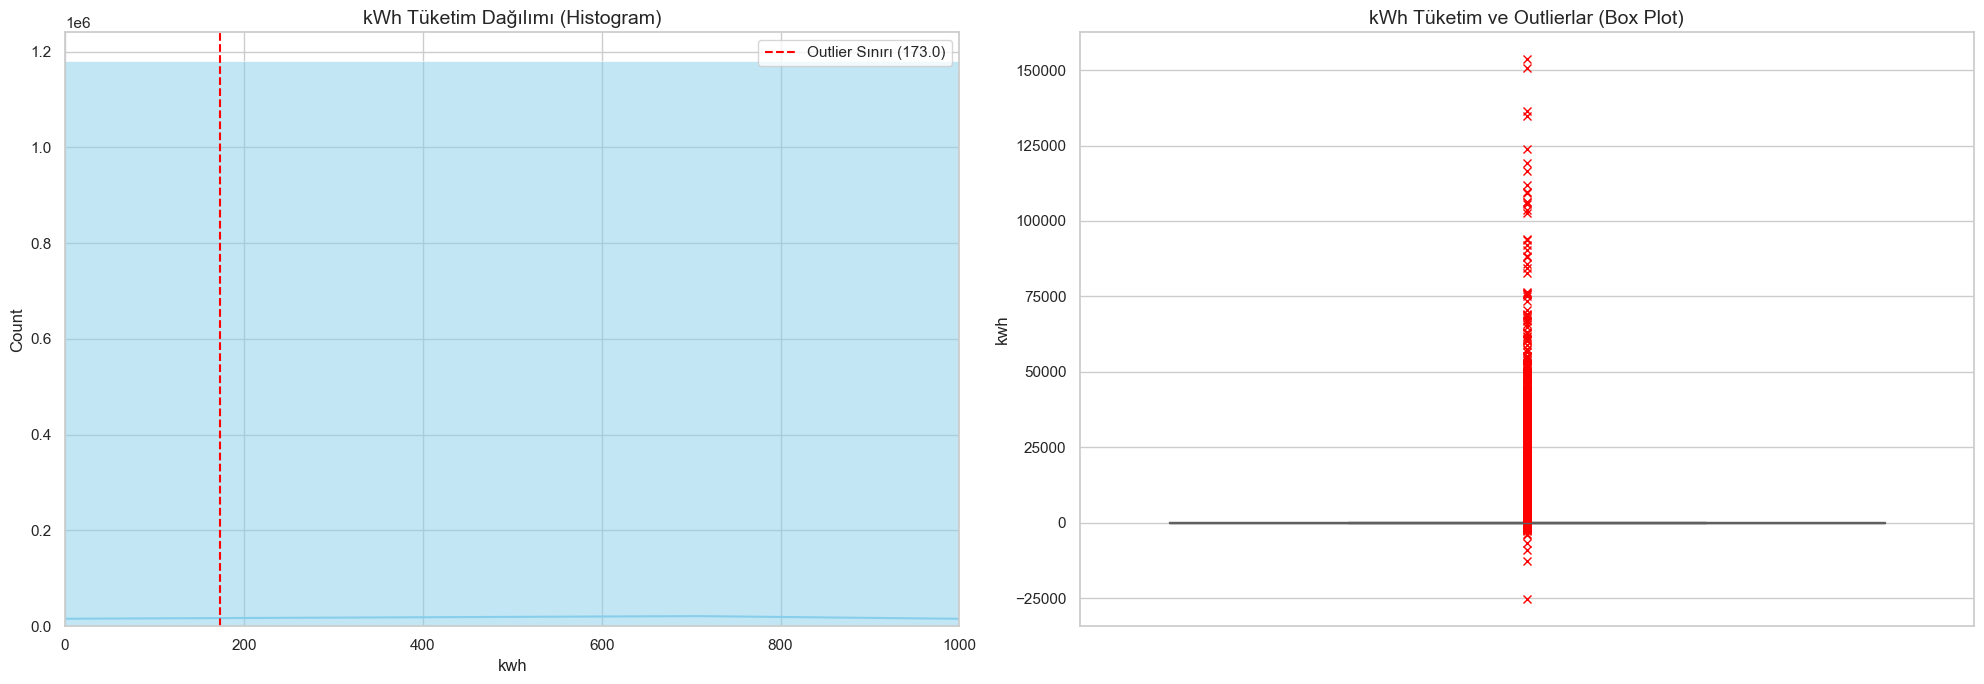

In [55]:

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

#Histogram 
# Verinin çoğu 0-500 aralığında olduğu için x eksenini kısıtlayarak detaylara bakalım
sns.histplot(df_tum_tahakkuk['kwh'], bins=100, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(ust_sinir, color='red',linestyle='--',label=f'Outlier Sınırı ({ust_sinir:.1f})')
axes[0].set_xlim(0, 1000) # Verinin yoğun olduğu bölgeye odaklan
axes[0].set_title('kWh Tüketim Dağılımı (Histogram)', fontsize=14)
axes[0].legend()

#Box Plot
sns.boxplot(y=df_tum_tahakkuk['kwh'], ax=axes[1], color='y', flierprops={"marker": "x", "markeredgecolor": "red"})
axes[1].set_title('kWh Tüketim ve Outlierlar (Box Plot)', fontsize=14)
# Box plot'ta da yoğun bölgeyi görmek için limit koyabilirsin:
# axes[1].set_xlim(-100, 1000) 

plt.tight_layout()
plt.show()